## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

In [2]:
import keras
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from numpy import random

Using TensorFlow backend.


### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

### Find no.of samples are there in training and test datasets

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_test.shape

(10000, 28, 28)

### Find dimensions of an image in the dataset

In [0]:
x_train[0].shape

(28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
# Convert train and test labels to one hot vectors
Y_train = keras.utils.to_categorical(y_train, num_classes=10, dtype='float32')
Y_test = keras.utils.to_categorical(y_test, num_classes=10, dtype='float32')

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
#Normalize both the train and test image data from 0-255 to 0-1
X_train= x_train/255.0 
X_test=x_test/255.0

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
#Reshape for image datageneration
X_train = X_train.reshape((60000, 28, 28, 1))
X_test = X_test.reshape((10000, 28, 28, 1))

### Import the necessary layers from keras to build the model

In [0]:
model = tf.keras.models.Sequential()
#normalize data
model.add(tf.keras.layers.BatchNormalization(input_shape=(28,28,1,)))

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [0]:
#Hidden layers
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

W0818 11:55:07.232170 140245352134528 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [0]:
#Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
#Model overview
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization (BatchNo (None, 28, 28, 1)         4         
_________________________________________________________________
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
flatten (Flatten)            (None, 18432)             0         
_________________________________________________________________
dense (Dense)                (None, 128)               2359424   
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1290      
Total params: 2,370,286
Trainable params: 2,370,284
Non-trainable params: 2
______________________________________________

In [0]:
#Early stopping with patience=5
es = EarlyStopping(monitor='val_acc', mode='max', patience=5)

#Save best model
best_save = ModelCheckpoint('model.h5', save_best_only=True, monitor='val_acc', mode='max')

In [0]:
# fit model
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=10, verbose=1, callbacks=[es,best_save])

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 11s 182us/sample - loss: 0.3589 - acc: 0.8695 - val_loss: 0.2880 - val_acc: 0.8975
Epoch 2/10
60000/60000 [==============================] - 9s 146us/sample - loss: 0.2162 - acc: 0.9209 - val_loss: 0.2498 - val_acc: 0.9110
Epoch 3/10
60000/60000 [==============================] - 9s 145us/sample - loss: 0.1473 - acc: 0.9445 - val_loss: 0.2461 - val_acc: 0.9166
Epoch 4/10
60000/60000 [==============================] - 9s 143us/sample - loss: 0.0947 - acc: 0.9646 - val_loss: 0.3157 - val_acc: 0.9130
Epoch 5/10
60000/60000 [==============================] - 9s 143us/sample - loss: 0.0623 - acc: 0.9778 - val_loss: 0.3476 - val_acc: 0.9101
Epoch 6/10
60000/60000 [==============================] - 9s 143us/sample - loss: 0.0428 - acc: 0.9848 - val_loss: 0.3994 - val_acc: 0.9146
Epoch 7/10
60000/60000 [==============================] - 9s 142us/sample - loss: 0.0313 - acc: 0.9889 - val_

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
model2 = tf.keras.models.Sequential()

#normalize data
model2.add(tf.keras.layers.BatchNormalization(input_shape=(28,28,1,)))

#Hidden layers
model2.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model2.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model2.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model2.add(tf.keras.layers.Dropout(0.25))
model2.add(tf.keras.layers.Flatten())
model2.add(tf.keras.layers.Dense(128, activation='relu'))

#Output layer
model2.add(tf.keras.layers.Dense(10, activation='softmax'))

#Compile model
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#Model overview
model2.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization_1 (Batch (None, 28, 28, 1)         4         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 32)        0         
_________________________________________________________________
dropout (Dropout)            (None, 12, 12, 32)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 4608)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)              

In [0]:
#Early stopping with patience=5
es = EarlyStopping(monitor='val_acc', mode='max', patience=5)

#Save best model
best_save2 = ModelCheckpoint('model2.h5', save_best_only=True, monitor='val_acc', mode='max')

# fit model
history2 = model2.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=10, verbose=1, callbacks=[es, best_save2])

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 8s 140us/sample - loss: 0.3677 - acc: 0.8679 - val_loss: 0.2843 - val_acc: 0.8998
Epoch 2/10
60000/60000 [==============================] - 8s 136us/sample - loss: 0.2447 - acc: 0.9097 - val_loss: 0.2367 - val_acc: 0.9169
Epoch 3/10
60000/60000 [==============================] - 8s 138us/sample - loss: 0.1976 - acc: 0.9274 - val_loss: 0.2260 - val_acc: 0.9188
Epoch 4/10
60000/60000 [==============================] - 8s 135us/sample - loss: 0.1634 - acc: 0.9384 - val_loss: 0.2240 - val_acc: 0.9225
Epoch 5/10
60000/60000 [==============================] - 8s 134us/sample - loss: 0.1360 - acc: 0.9494 - val_loss: 0.2419 - val_acc: 0.9201
Epoch 6/10
60000/60000 [==============================] - 8s 135us/sample - loss: 0.1145 - acc: 0.9564 - val_loss: 0.2420 - val_acc: 0.9226
Epoch 7/10
60000/60000 [==============================] - 8s 134us/sample - loss: 0.0959 - acc: 0.9630 - val_l

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
#Import the ImageDataGenrator from keras
img_generator= tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=20,
                                                                width_shift_range=0.2,
                                                                height_shift_range=0.2,
                                                                shear_range=0.2,
                                                                zoom_range=0.2,
                                                                )


In [0]:
img_generator.fit(X_train)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

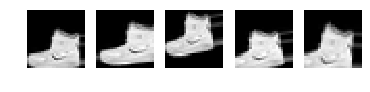

In [0]:
from matplotlib import pyplot as plt
gen = img_generator.flow(X_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [0]:
# fits the model on batches with real-time data augmentation:

#Save best model
best_save3 = ModelCheckpoint('model3.h5', save_best_only=True, monitor='val_acc', mode='max')

history3 = model2.fit_generator(img_generator.flow(X_train, Y_train, batch_size=32),validation_data=(X_test, Y_test),
                    steps_per_epoch=len(X_train) / 60, epochs=10, callbacks = [best_save3])

Epoch 1/10
1000/1000 [==============================] - 11s 11ms/step - loss: 0.8877 - acc: 0.6754 - val_loss: 0.3895 - val_acc: 0.8543
Epoch 2/10
1000/1000 [==============================] - 11s 11ms/step - loss: 0.6553 - acc: 0.7547 - val_loss: 0.3802 - val_acc: 0.8603
Epoch 3/10
1000/1000 [==============================] - 11s 11ms/step - loss: 0.6058 - acc: 0.7740 - val_loss: 0.3612 - val_acc: 0.8676
Epoch 4/10
1000/1000 [==============================] - 11s 11ms/step - loss: 0.5691 - acc: 0.7845 - val_loss: 0.3746 - val_acc: 0.8584
Epoch 5/10
1000/1000 [==============================] - 11s 11ms/step - loss: 0.5381 - acc: 0.8007 - val_loss: 0.3561 - val_acc: 0.8680
Epoch 6/10
1000/1000 [==============================] - 11s 11ms/step - loss: 0.5331 - acc: 0.8010 - val_loss: 0.3522 - val_acc: 0.8709
Epoch 7/10
1000/1000 [==============================] - 11s 11ms/step - loss: 0.5104 - acc: 0.8113 - val_loss: 0.3342 - val_acc: 0.8746
Epoch 8/10
1000/1000 [==========================

###  Report the final train and validation accuracy

In [0]:
#Evaluate final model from above steps (train)
model2.evaluate(X_train,Y_train)

60000/60000 [==============================] - 4s 74us/sample - loss: 0.2889 - acc: 0.8903


[0.2889132287065188, 0.89031667]

In [0]:
#Evaluate final model from above steps (test)
model2.evaluate(X_test,Y_test)

10000/10000 [==============================] - 1s 74us/sample - loss: 0.3333 - acc: 0.8760


[0.3332788883924484, 0.876]

In [0]:
# Loading best model fit of all the epochs tried above (achieved before ImageDataGenrator)
model_final = tf.keras.models.load_model('model2.h5')

W0818 11:59:39.779191 140245352134528 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:97: calling Zeros.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
W0818 11:59:39.782243 140245352134528 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:97: calling Ones.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
W0818 11:59:39.836424 140245352134528 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:97: calling GlorotUniform.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecat

In [0]:
#Evaluate final model from above steps (train)
model.evaluate(X_train,Y_train)

60000/60000 [==============================] - 5s 78us/sample - loss: 0.0182 - acc: 0.9940


[0.01817237833526548, 0.99395]

In [0]:
#Evaluate final model from above steps (test)
model.evaluate(X_test,Y_test)

10000/10000 [==============================] - 1s 79us/sample - loss: 0.5303 - acc: 0.9085


[0.5303085872795433, 0.9085]

## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
import tensorflow as tf

### **Load CIFAR10 dataset**

In [0]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
#Normalize both the train and test image data from 0-255 to 0-1
X_train, X_test = x_train/255.0, x_test/255.0

In [0]:
data_gen_fn = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True,
                                                               width_shift_range=0.2,
                                                               height_shift_range=0.2,
                                                               rotation_range=30,
                                                               )

### **Prepare/fit the generator.**

In [0]:
data_gen_fn.fit(X_train)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

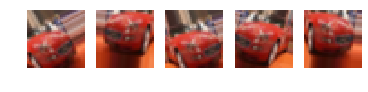

In [0]:
from matplotlib import pyplot as plt
gen = data_gen_fn.flow(X_train[5:6], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()